<a href="https://colab.research.google.com/github/ARMANDOTORRES81/r-basic/blob/master/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tarea 1**

Modifica el diccionario graph en el código anterior. Añade un nuevo nodo llamado 'F' que conecte 'B' con la 'Meta' con un costo muy bajo.

Ejecuta el código y explica en comentarios por qué BFS sigue eligiendo la misma ruta aunque ahora exista una más "barata" en términos de costo.


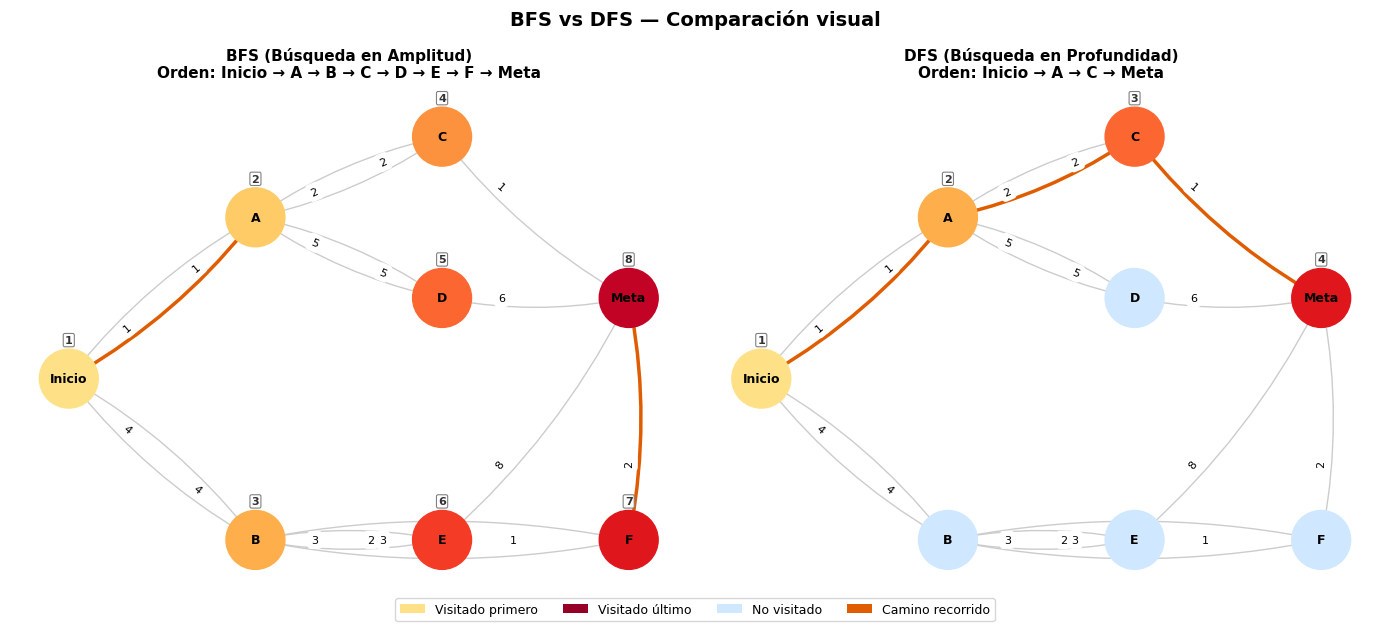

In [5]:
import collections
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Definición del Espacio de Estados (Un grafo de una ciudad pequeña)
# Los nodos son puntos de control y las conexiones son calles con su costo (distancia)
graph = {
    'Inicio': [('A', 1), ('B', 4)],
    'A': [('Inicio', 1), ('C', 2), ('D', 5)],
    'B': [('Inicio', 4), ('E', 3), ('F', 2)],
    'C': [('A', 2), ('Meta', 1)],
    'D': [('A', 5), ('Meta', 6)],
    'E': [('B', 3), ('Meta', 8)],
    'F': [('B', 1), ('Meta', 2)],
    'Meta': []
}
# 2. Visualización mejorada
def visualize_search(visited_order, title,ax):
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors:
            G.add_edge(node, neighbor, weight=weight)


    # Posiciones fijas para reproducibilidad
    pos = {
        'Inicio': (0, 1), 'A': (1, 2), 'B': (1, 0),
        'C': (2, 2.5),    'D': (2, 1.5), 'E': (2, 0),
        'F': (3, 0),
        'Meta': (3, 1.5),
    }

        # Colores por orden de visita (amarillo → rojo)
    cmap = plt.cm.YlOrRd
    num_nodes = len(visited_order)
    color_map = {n: cmap(0.2 + (i / num_nodes) * 0.75)
                 for i, n in enumerate(visited_order)}
    node_colors = [color_map.get(node, '#d0e8ff') for node in G.nodes()]

    # Aristas del camino recorrido en naranja
    path_edges = [(visited_order[i], visited_order[i+1])
                  for i in range(len(visited_order)-1)
                  if G.has_edge(visited_order[i], visited_order[i+1])]
    edge_colors = ['#e05c00' if e in path_edges else '#cccccc' for e in G.edges()]
    edge_widths = [2.5 if e in path_edges else 1.0 for e in G.edges()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1800)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels=nx.get_edge_attributes(G, 'weight'),
                                 ax=ax, font_size=8, label_pos=0.3)

    # Número de orden encima de cada nodo visitado
    for i, node in enumerate(visited_order):
        x, y = pos[node]
        ax.text(x, y + 0.22, str(i+1), ha='center', fontsize=8,
                fontweight='bold', color='#333333',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='gray', linewidth=0.8))

    ax.set_title(f'{title}\nOrden: {" → ".join(visited_order)}',
                 fontsize=11, fontweight='bold', pad=12)
    ax.axis('off')

# 3. Implementación de BFS (Búsqueda en Amplitud)
def bfs(start, goal):
    queue = collections.deque([start])
    visited = []
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            if node == goal: break
            neighbors = [n[0] for n in graph.get(node, [])]
            queue.extend(neighbors)
    return visited

# 4. Implementación de DFS (Búsqueda en Profundidad)
def dfs(start, goal):
    stack = [start]
    visited = []
    while stack:
        node = stack.pop() # Sacamos el último (LIFO)
        if node not in visited:
            visited.append(node)
            if node == goal: break
            neighbors = [n[0] for n in graph.get(node, [])]
            stack.extend(reversed(neighbors))
    return visited

#5 Ejecución y Visualización
bfs_result = bfs('Inicio', 'Meta')
dfs_result = dfs('Inicio', 'Meta')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('BFS vs DFS — Comparación visual', fontsize=14, fontweight='bold')

visualize_search(bfs_result, 'BFS (Búsqueda en Amplitud)', axes[0])
visualize_search(dfs_result, 'DFS (Búsqueda en Profundidad)', axes[1])

legend_elements = [
    mpatches.Patch(facecolor=plt.cm.YlOrRd(0.2),  label='Visitado primero'),
    mpatches.Patch(facecolor=plt.cm.YlOrRd(0.95), label='Visitado último'),
    mpatches.Patch(facecolor='#d0e8ff',            label='No visitado'),
    mpatches.Patch(facecolor='#e05c00',            label='Camino recorrido'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()



BFS, tiene la misma ruta debido a que recorre todos los nodos, si importar cuantos mas pongamos

# **QUIZZ 1**
**¿Qué define a una búsqueda como "no informada"?**
*Se define cuando la IA no sabe si un movimiento se acerca a la meta, solo sabe si ya llego o no*

**En un laberinto con caminos infinitos, ¿qué algoritmo es más peligroso usar**
*DFS*

**¿Cuál es la principal ventaja de BFS?**
*Siempre encuentra el camino más corto*

**¿Qué es un "operador" en IA?**
Son reglas que nos permiten pasar de un estado a otro
Si el costo de las calles es diferente (ej. una calle tiene baches y otra no) *texto en cursiva*

**¿qué algoritmo es mejor?**
*UCS*


## **Tarea2**

Crea un script en Python que compare el tiempo de ejecución de una búsqueda BFS en un grafo de 10 nodos contra uno de 25 nodos.

Imprime la diferencia de tiempo.

Pista: Usa time.perf_counter() para mayor precisión en mediciones muy pequeñas.